# Question 1


In [11]:
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = datasets.load_iris()

X = iris.data
y = iris.target

# Two new features
petal_area = X[:, 2] * X[:, 3]
sepal_ratio = X[:, 0] / X[:, 1]

# Combine the new features into a new feature matrix X
X_new = np.column_stack((petal_area, sepal_ratio))

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_new,
    y,
    test_size=0.40,
    train_size=0.60,
    random_state=123,
    shuffle=True,
    stratify=y,
)

In [12]:
# Train the SVM
clf = svm.SVC()
clf.fit(X_train, y_train)

# Predict test samples and calculate classification accuracy
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Classification Accuracy with 2 New Features: {acc:.4f}")

Classification Accuracy with 2 New Features: 0.9500


# Question 2



In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Load MNIST Digits dataset
digits = load_digits()
X_all = digits.data  # Shape: (1797, 64) - considers every pixel as a feature
y_all = digits.target

# Filter only even-numbered digits
even_mask = (y_all % 2) == 0
X_even = X_all[even_mask]
y_even = y_all[even_mask]

# Randomly split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_even, y_even, test_size=0.30, random_state=42, stratify=y_even
)

In [14]:
# Train k-NN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict on unseen test data
y_pred = knn.predict(X_test)

# Compute confusion matrix for even digits
even_labels = [0, 2, 4, 6, 8]
cm = confusion_matrix(y_test, y_pred, labels=even_labels)


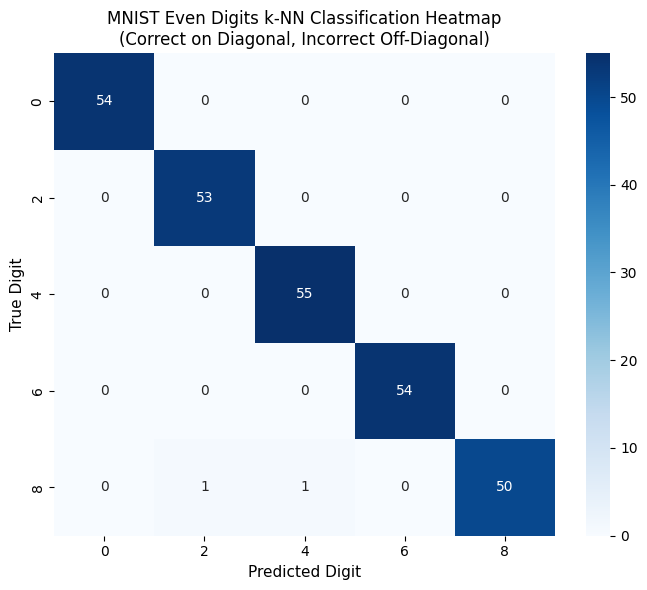


Total number of 6's in the test set: 54
Number of 6's correctly classified: 54
Accuracy on digit 6: 100.00%


In [15]:
# Plot results using a Heatmap
plt.figure(figsize=(7, 6), dpi=100)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=even_labels,
    yticklabels=even_labels,
    cbar=True,
)
plt.title(
    "MNIST Even Digits k-NN Classification Heatmap\n(Correct on Diagonal, Incorrect Off-Diagonal)",
    fontsize=12,
)
plt.xlabel("Predicted Digit", fontsize=11)
plt.ylabel("True Digit", fontsize=11)
plt.tight_layout()
plt.show()

# Print how many 6's in test set were correctly classified
total_6s = np.sum(y_test == 6)
idx_6 = even_labels.index(6)
correct_6s = cm[idx_6, idx_6]
print(f"\nTotal number of 6's in the test set: {total_6s}")
print(f"Number of 6's correctly classified: {correct_6s}")
print(f"Accuracy on digit 6: {correct_6s / total_6s * 100:.2f}%")

# Question 3


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets
from sklearn.cluster import KMeans

# Load Iris dataset and select three features
iris = datasets.load_iris()
feature_idx = [0, 1, 2]
X = iris.data[:, feature_idx]
feature_names = [iris.feature_names[i] for i in feature_idx]

# Custom k-means
class CustomKMeans:

    def __init__(self, k=3, max_iters=300, random_state=42):
        self.k = k
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None

    def fit(self, X):
        np.random.seed(self.random_state)
        # Randomly initialize centroids from the dataset points
        random_indices = np.random.choice(len(X), size=self.k, replace=False)
        self.centroids = X[random_indices].copy()

        for _ in range(self.max_iters):
            # Assignment Step: Compute Euclidean distance to all centroids
            # distances shape: (n_samples, k)
            distances = np.linalg.norm(
                X[:, np.newaxis, :] - self.centroids, axis=2
            )
            labels = np.argmin(distances, axis=1)

            # Update Step: Recalculate centroids as cluster means
            new_centroids = np.zeros_like(self.centroids)
            for j in range(self.k):
                pts_in_cluster = X[labels == j]
                if len(pts_in_cluster) > 0:
                    new_centroids[j] = pts_in_cluster.mean(axis=0)
                else:
                    new_centroids[j] = X[np.random.choice(len(X))]

            # Convergence Check: Centroids did not change
            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids

        self.labels_ = labels
        return self

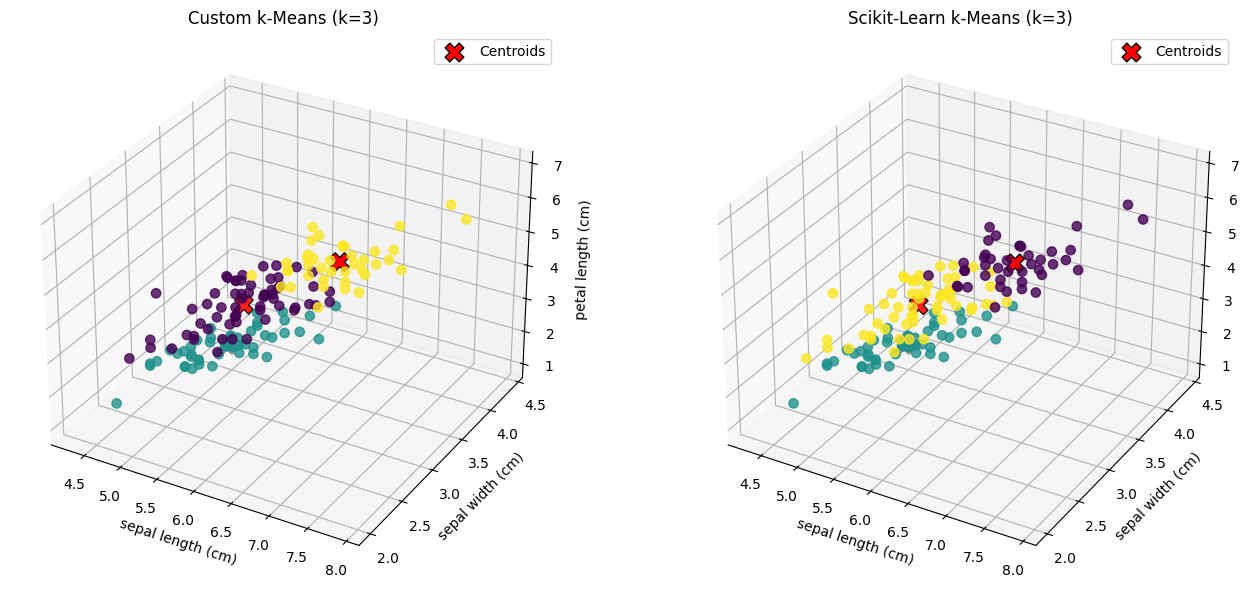

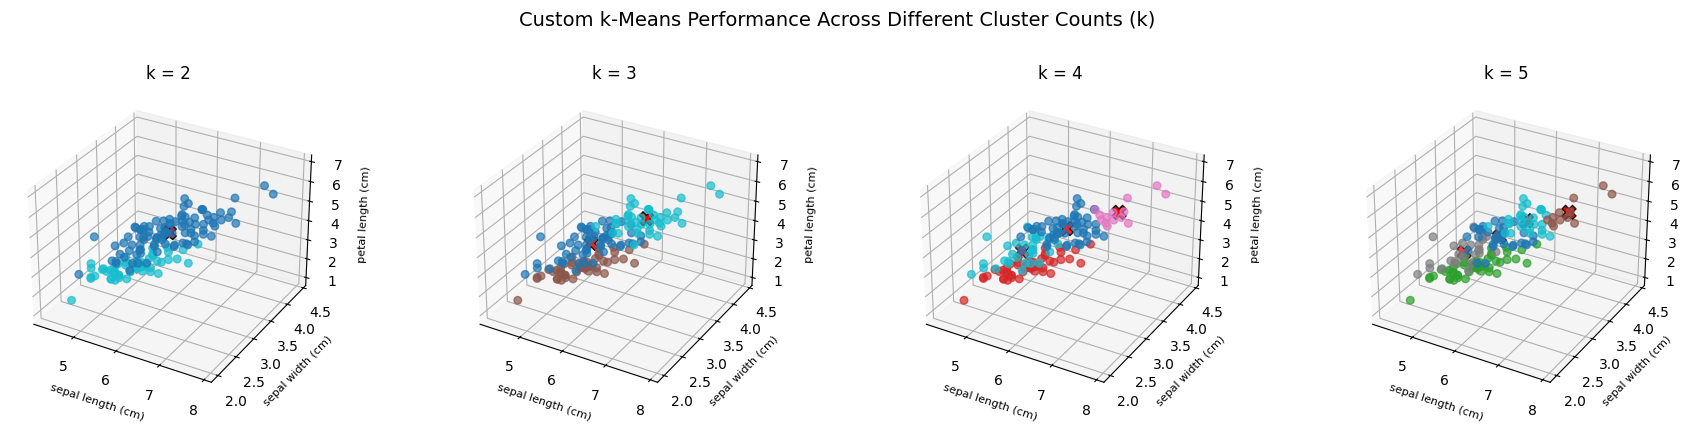

In [17]:
# Fit Custom k-means and Scikit-Learn KMeans (k=3)
k = 3
custom_km = CustomKMeans(k=k, random_state=42).fit(X)
sklearn_km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)

# 3D Visual Comparison: Custom vs. Sklearn Implementation
fig = plt.figure(figsize=(14, 6), dpi=100)

# Plot: Custom k-means
ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(
    X[:, 0],
    X[:, 1],
    X[:, 2],
    c=custom_km.labels_,
    cmap="viridis",
    s=45,
    alpha=0.8,
)
ax1.scatter(
    custom_km.centroids[:, 0],
    custom_km.centroids[:, 1],
    custom_km.centroids[:, 2],
    c="red",
    marker="X",
    s=180,
    edgecolor="black",
    label="Centroids",
)
ax1.set_title(f"Custom k-Means (k={k})", fontsize=12)
ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])
ax1.set_zlabel(feature_names[2])
ax1.legend()

# Plot: Scikit-Learn KMeans
ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(
    X[:, 0],
    X[:, 1],
    X[:, 2],
    c=sklearn_km.labels_,
    cmap="viridis",
    s=45,
    alpha=0.8,
)
ax2.scatter(
    sklearn_km.cluster_centers_[:, 0],
    sklearn_km.cluster_centers_[:, 1],
    sklearn_km.cluster_centers_[:, 2],
    c="red",
    marker="X",
    s=180,
    edgecolor="black",
    label="Centroids",
)
ax2.set_title(f"Scikit-Learn k-Means (k={k})", fontsize=12)
ax2.set_xlabel(feature_names[0])
ax2.set_ylabel(feature_names[1])
ax2.set_zlabel(feature_names[2])
ax2.legend()

plt.tight_layout()
plt.show()

# Plot: Varying the Number of Clusters (k = 2, 3, 4, 5)
fig, axes = plt.subplots(
    1, 4, figsize=(18, 4), dpi=100, subplot_kw={"projection": "3d"}
)
k_values = [2, 3, 4, 5]

for ax, k_val in zip(axes, k_values):
    km_vary = CustomKMeans(k=k_val, random_state=42).fit(X)
    ax.scatter(
        X[:, 0],
        X[:, 1],
        X[:, 2],
        c=km_vary.labels_,
        cmap="tab10",
        s=30,
        alpha=0.7,
    )
    ax.scatter(
        km_vary.centroids[:, 0],
        km_vary.centroids[:, 1],
        km_vary.centroids[:, 2],
        c="red",
        marker="X",
        s=100,
        edgecolor="k",
    )
    ax.set_title(f"k = {k_val}")
    ax.set_xlabel(feature_names[0], fontsize=8)
    ax.set_ylabel(feature_names[1], fontsize=8)
    ax.set_zlabel(feature_names[2], fontsize=8)

plt.suptitle(
    "Custom k-Means Performance Across Different Cluster Counts (k)",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()